# Housing & Sanitation + Education & Sports Analysis
## Provincial and District-Level Behavioral Patterns in Mouza Census 2020

This notebook analyzes infrastructure patterns by:
1. **Province-Level Overview**: Understanding provincial variations in housing, sanitation, education & sports
2. **District Behavior Clustering**: Identifying how many districts exhibit specific infrastructure ratios
3. **Comparative Analysis**: "X districts in Province Y have more than Z% of Kacha/Pucca houses"

In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

# Load the dataset
df = pd.read_csv('Mouza_Census_ReducedRenamed.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Districts: {df['Name of District'].nunique()}")
print(f"Total Provinces: {df['Name of Province'].nunique()}")
print(f"Total Divisions: {df['Name of Division'].nunique()}")
print(f"\nProvinces in dataset:")
print(df['Name of Province'].value_counts())

Dataset Shape: (151, 237)
Total Districts: 151
Total Provinces: 7
Total Divisions: 37

Provinces in dataset:
Name of Province
PUNJAB                         37
KHYBER PAKHTUNKHWA             35
BALOCHISTAN                    33
SINDH                          25
GILGIT BALTISTAN               10
AZAD JAMMU AND KASHMIR         10
ISLAMABAD CAPITAL TERRITORY     1
Name: count, dtype: int64


---
## Part 1: Housing & Sanitation Analysis
### Focus: Provincial Patterns and District Clustering Behavior

In [10]:
# Housing Construction Type Analysis - Provincial Behavior
print("="*100)
print("HOUSING CONSTRUCTION PATTERNS: Pucca vs Kutcha Houses by Province")
print("="*100)

# Key columns for housing analysis
housing_cols = ['Ratio of mouzas with Pucca houses', 'Ratio of mouzas with Kutcha houses', 
                'Ratio of mouzas with Pucca/Kutcha houses', 'Ratio of mouzas with Other houses']

# Province-wise summary
province_housing = df.groupby('Name of Province')[housing_cols].mean()
print("\nAverage Housing Type Ratios by Province:")
print(province_housing.round(4))

# District clustering analysis
print("\n" + "="*100)
print("DISTRICT CLUSTERING ANALYSIS: How many districts have what proportion of Kutcha houses?")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    # Count districts by Kutcha house ranges
    very_high_kutcha = (province_data['Ratio of mouzas with Kutcha houses'] > 0.5).sum()
    high_kutcha = ((province_data['Ratio of mouzas with Kutcha houses'] > 0.3) & 
                   (province_data['Ratio of mouzas with Kutcha houses'] <= 0.5)).sum()
    moderate_kutcha = ((province_data['Ratio of mouzas with Kutcha houses'] > 0.1) & 
                       (province_data['Ratio of mouzas with Kutcha houses'] <= 0.3)).sum()
    low_kutcha = (province_data['Ratio of mouzas with Kutcha houses'] <= 0.1).sum()
    
    print(f"  • {very_high_kutcha} districts have >50% mouzas with Kutcha houses (Very High)")
    print(f"  • {high_kutcha} districts have 30-50% mouzas with Kutcha houses (High)")
    print(f"  • {moderate_kutcha} districts have 10-30% mouzas with Kutcha houses (Moderate)")
    print(f"  • {low_kutcha} districts have <10% mouzas with Kutcha houses (Low)")
    
    # Pucca houses
    high_pucca = (province_data['Ratio of mouzas with Pucca houses'] > 0.3).sum()
    print(f"  • {high_pucca} districts have >30% mouzas with Pucca houses")

HOUSING CONSTRUCTION PATTERNS: Pucca vs Kutcha Houses by Province

Average Housing Type Ratios by Province:
                             Ratio of mouzas with Pucca houses  \
Name of Province                                                 
AZAD JAMMU AND KASHMIR                                  0.3052   
BALOCHISTAN                                             0.0193   
GILGIT BALTISTAN                                        0.1354   
ISLAMABAD CAPITAL TERRITORY                             0.8056   
KHYBER PAKHTUNKHWA                                      0.1204   
PUNJAB                                                  0.5788   
SINDH                                                   0.0594   

                             Ratio of mouzas with Kutcha houses  \
Name of Province                                                  
AZAD JAMMU AND KASHMIR                                   0.0932   
BALOCHISTAN                                              0.6813   
GILGIT BALTISTAN             

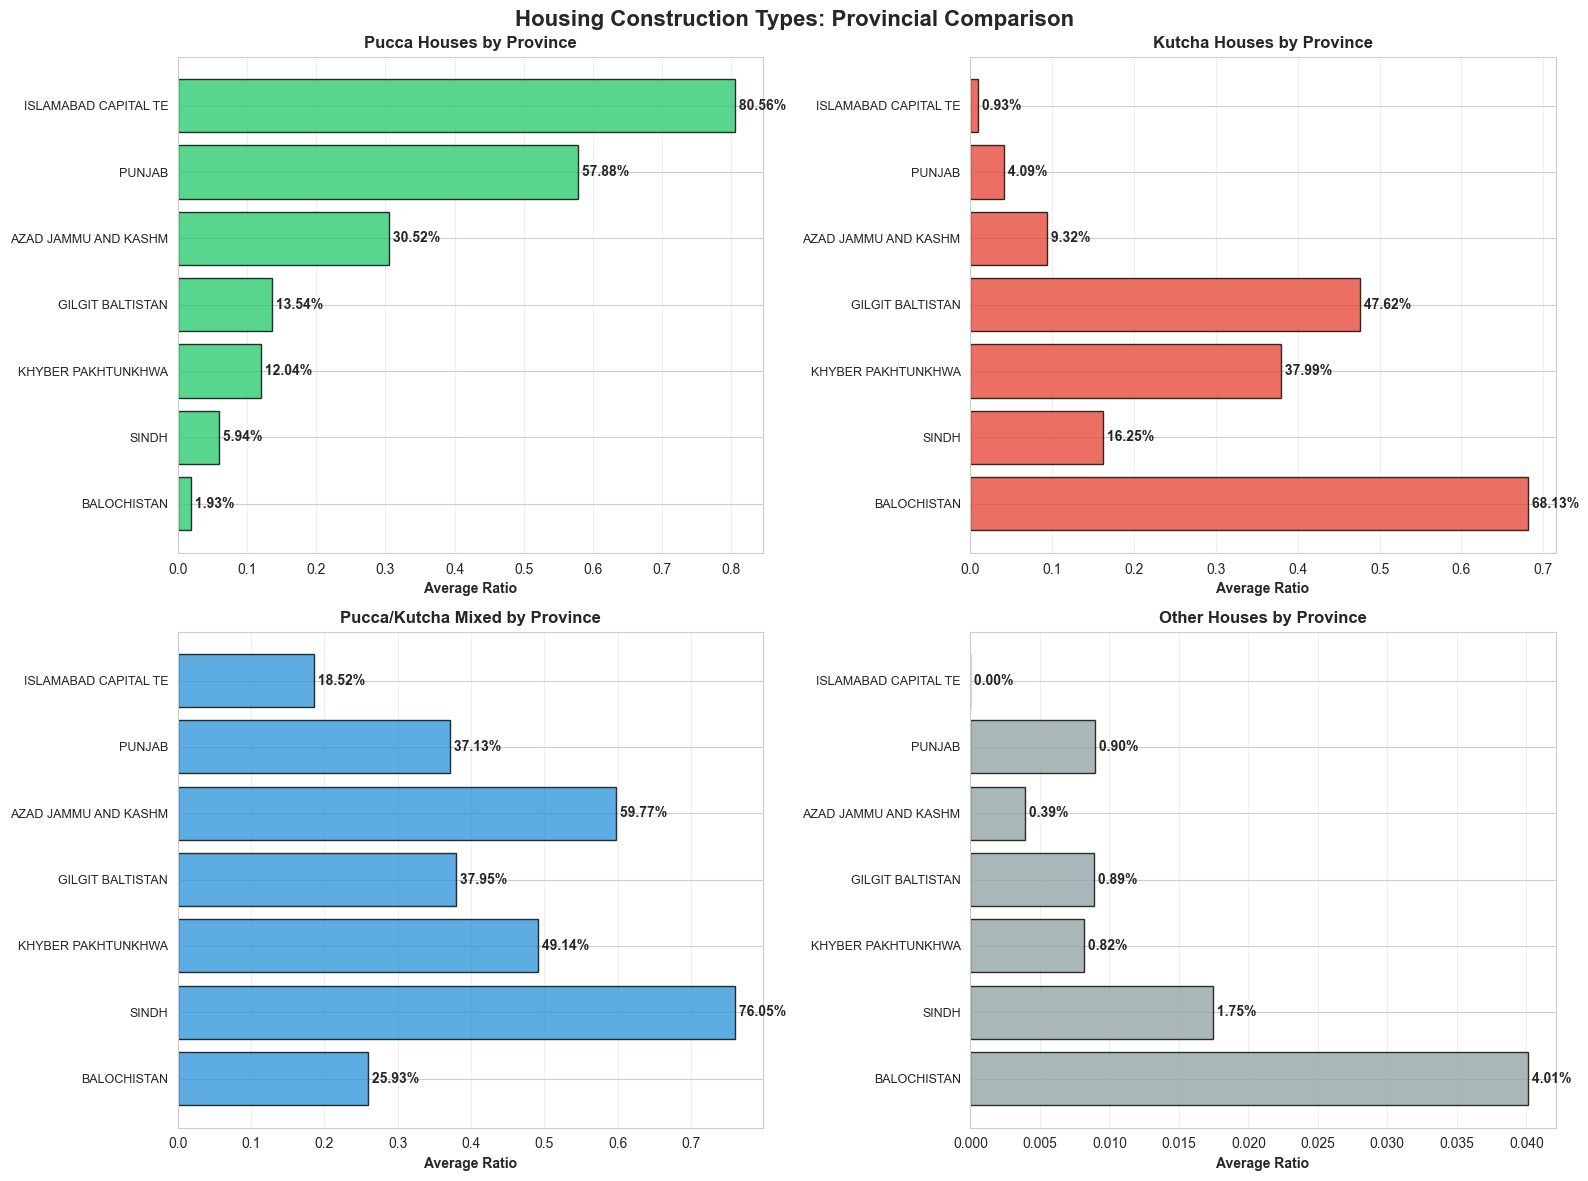


DISTRICT DISTRIBUTION WITHIN EACH PROVINCE

KHYBER PAKHTUNKHWA:
  Pucca houses  - Min: 0.00%, Max: 52.94%, Median: 3.90%
  Kutcha houses - Min: 2.44%, Max: 96.03%, Median: 29.15%

PUNJAB:
  Pucca houses  - Min: 5.73%, Max: 98.54%, Median: 57.12%
  Kutcha houses - Min: 0.00%, Max: 41.34%, Median: 2.09%

SINDH:
  Pucca houses  - Min: 0.85%, Max: 38.46%, Median: 3.59%
  Kutcha houses - Min: 0.00%, Max: 48.29%, Median: 12.12%

BALOCHISTAN:
  Pucca houses  - Min: 0.00%, Max: 11.94%, Median: 1.13%
  Kutcha houses - Min: 8.70%, Max: 96.81%, Median: 74.26%

ISLAMABAD CAPITAL TERRITORY:
  Pucca houses  - Min: 80.56%, Max: 80.56%, Median: 80.56%
  Kutcha houses - Min: 0.93%, Max: 0.93%, Median: 0.93%

GILGIT BALTISTAN:
  Pucca houses  - Min: 0.00%, Max: 56.41%, Median: 4.23%
  Kutcha houses - Min: 2.56%, Max: 100.00%, Median: 41.11%

AZAD JAMMU AND KASHMIR:
  Pucca houses  - Min: 0.00%, Max: 78.15%, Median: 38.41%
  Kutcha houses - Min: 0.00%, Max: 69.32%, Median: 2.13%


In [11]:
# Visualize Housing Construction Distribution by Province
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Housing Construction Types: Provincial Comparison', fontsize=16, fontweight='bold')

housing_types = ['Ratio of mouzas with Pucca houses', 'Ratio of mouzas with Kutcha houses',
                 'Ratio of mouzas with Pucca/Kutcha houses', 'Ratio of mouzas with Other houses']
titles = ['Pucca Houses', 'Kutcha Houses', 'Pucca/Kutcha Mixed', 'Other Houses']
colors = ['#2ECC71', '#E74C3C', '#3498DB', '#95A5A6']

# Fix a single province order
province_order = df.groupby('Name of Province')[housing_types[0]].mean() \
                   .sort_values(ascending=False).index

for idx, (col, title, color) in enumerate(zip(housing_types, titles, colors)):
    ax = axes[idx // 2, idx % 2]

    # Province-wise average using the fixed order
    province_avg = df.groupby('Name of Province')[col].mean().loc[province_order]

    ax.barh(range(len(province_avg)), province_avg.values, color=color, alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(province_avg)))
    ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
    ax.set_xlabel('Average Ratio', fontweight='bold')
    ax.set_title(f'{title} by Province', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    for i, v in enumerate(province_avg.values):
        ax.text(v, i, f' {v:.2%}', va='center', fontweight='bold')


plt.tight_layout()
plt.show()

# District distribution within provinces
print("\n" + "="*100)
print("DISTRICT DISTRIBUTION WITHIN EACH PROVINCE")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    print(f"\n{province}:")
    print(f"  Pucca houses  - Min: {province_data['Ratio of mouzas with Pucca houses'].min():.2%}, "
          f"Max: {province_data['Ratio of mouzas with Pucca houses'].max():.2%}, "
          f"Median: {province_data['Ratio of mouzas with Pucca houses'].median():.2%}")
    print(f"  Kutcha houses - Min: {province_data['Ratio of mouzas with Kutcha houses'].min():.2%}, "
          f"Max: {province_data['Ratio of mouzas with Kutcha houses'].max():.2%}, "
          f"Median: {province_data['Ratio of mouzas with Kutcha houses'].median():.2%}")

TOILET FACILITIES: Inside vs Outside Toilet Patterns

Average Toilet Facility Ratios by Province:
                             Ratio of mouzas with outside toilet facility  \
Name of Province                                                            
AZAD JAMMU AND KASHMIR                                             0.0553   
BALOCHISTAN                                                        0.6884   
GILGIT BALTISTAN                                                   0.2009   
ISLAMABAD CAPITAL TERRITORY                                        0.0000   
KHYBER PAKHTUNKHWA                                                 0.2506   
PUNJAB                                                             0.1219   
SINDH                                                              0.2869   

                             Ratio of mouzas with inside toilet facility  
Name of Province                                                          
AZAD JAMMU AND KASHMIR                                    

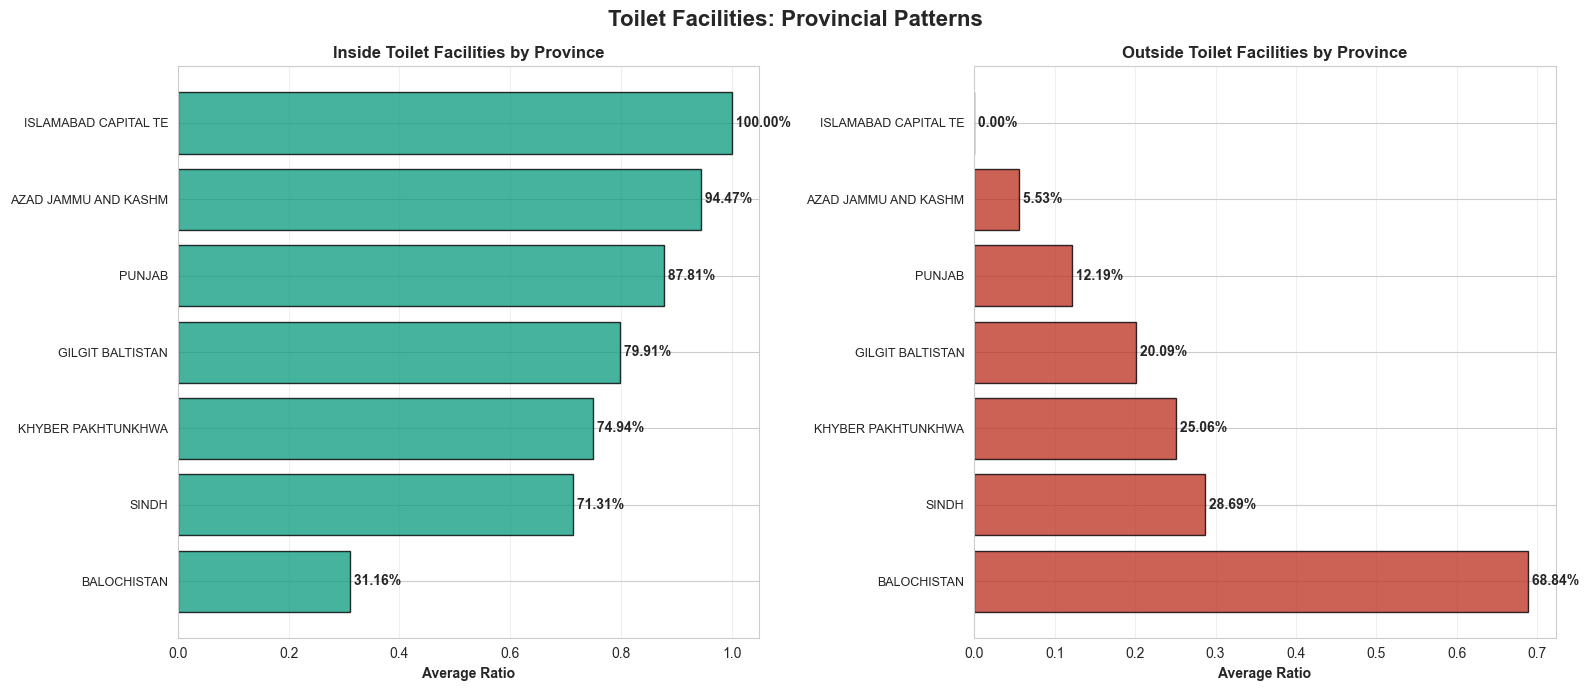

In [12]:
# Toilet Facilities Analysis - Provincial and District Clustering
print("="*100)
print("TOILET FACILITIES: Inside vs Outside Toilet Patterns")
print("="*100)

# Province-wise toilet facilities
toilet_cols = ['Ratio of mouzas with outside toilet facility', 'Ratio of mouzas with inside toilet facility']
province_toilets = df.groupby('Name of Province')[toilet_cols].mean()

print("\nAverage Toilet Facility Ratios by Province:")
print(province_toilets.round(4))

# District clustering by inside toilet facility
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Inside Toilet Facility Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    # Count districts by inside toilet ranges
    very_high = (province_data['Ratio of mouzas with inside toilet facility'] > 0.8).sum()
    high = ((province_data['Ratio of mouzas with inside toilet facility'] > 0.6) & 
            (province_data['Ratio of mouzas with inside toilet facility'] <= 0.8)).sum()
    moderate = ((province_data['Ratio of mouzas with inside toilet facility'] > 0.4) & 
                (province_data['Ratio of mouzas with inside toilet facility'] <= 0.6)).sum()
    low = ((province_data['Ratio of mouzas with inside toilet facility'] > 0.2) & 
           (province_data['Ratio of mouzas with inside toilet facility'] <= 0.4)).sum()
    very_low = (province_data['Ratio of mouzas with inside toilet facility'] <= 0.2).sum()
    
    print(f"  • {very_high} districts: >80% mouzas have inside toilets (Excellent)")
    print(f"  • {high} districts: 60-80% mouzas have inside toilets (Good)")
    print(f"  • {moderate} districts: 40-60% mouzas have inside toilets (Moderate)")
    print(f"  • {low} districts: 20-40% mouzas have inside toilets (Poor)")
    print(f"  • {very_low} districts: <20% mouzas have inside toilets (Critical)")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Toilet Facilities: Provincial Patterns', fontsize=16, fontweight='bold')

# Fix a single and consistent province order (pick inside toilet metric for ordering)
province_order = df.groupby('Name of Province')['Ratio of mouzas with inside toilet facility'] \
                   .mean().sort_values(ascending=False).index

# Inside toilet facilities
ax = axes[0]
province_avg = df.groupby('Name of Province')['Ratio of mouzas with inside toilet facility'] \
                 .mean().loc[province_order]

ax.barh(range(len(province_avg)), province_avg.values, color='#16A085', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(province_avg)))
ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
ax.set_xlabel('Average Ratio', fontweight='bold')
ax.set_title('Inside Toilet Facilities by Province', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
for i, v in enumerate(province_avg.values):
    ax.text(v, i, f' {v:.2%}', va='center', fontweight='bold')

# Outside toilet facilities
ax = axes[1]
province_avg = df.groupby('Name of Province')['Ratio of mouzas with outside toilet facility'] \
                 .mean().loc[province_order]

ax.barh(range(len(province_avg)), province_avg.values, color='#C0392B', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(province_avg)))
ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
ax.set_xlabel('Average Ratio', fontweight='bold')
ax.set_title('Outside Toilet Facilities by Province', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
for i, v in enumerate(province_avg.values):
    ax.text(v, i, f' {v:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


WASTE MANAGEMENT INFRASTRUCTURE

Average Waste Management Ratios by Province:
                             Ratio of mouzas with no waste management  \
Name of Province                                                        
AZAD JAMMU AND KASHMIR                                         0.9359   
BALOCHISTAN                                                    0.9673   
GILGIT BALTISTAN                                               0.9082   
ISLAMABAD CAPITAL TERRITORY                                    0.7778   
KHYBER PAKHTUNKHWA                                             0.9372   
PUNJAB                                                         0.8978   
SINDH                                                          0.8725   

                             Ratio of mouzas with any waste management  \
Name of Province                                                         
AZAD JAMMU AND KASHMIR                                          0.0641   
BALOCHISTAN                               

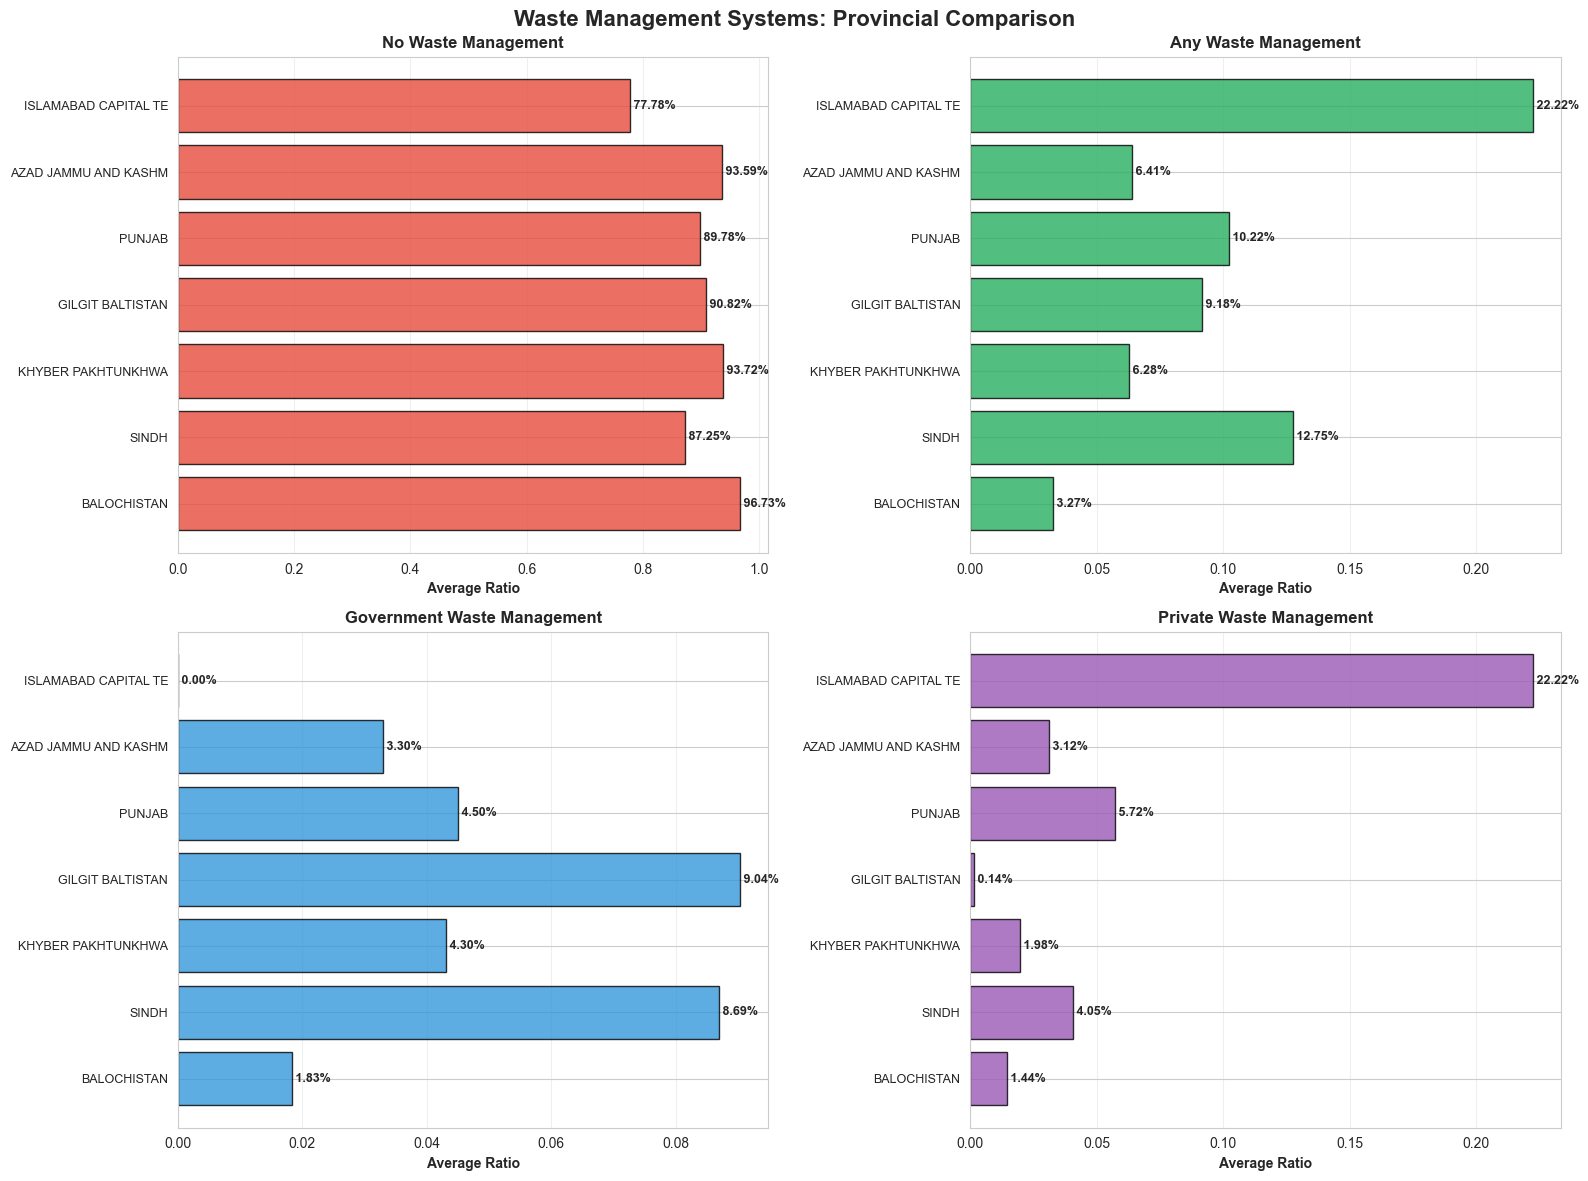

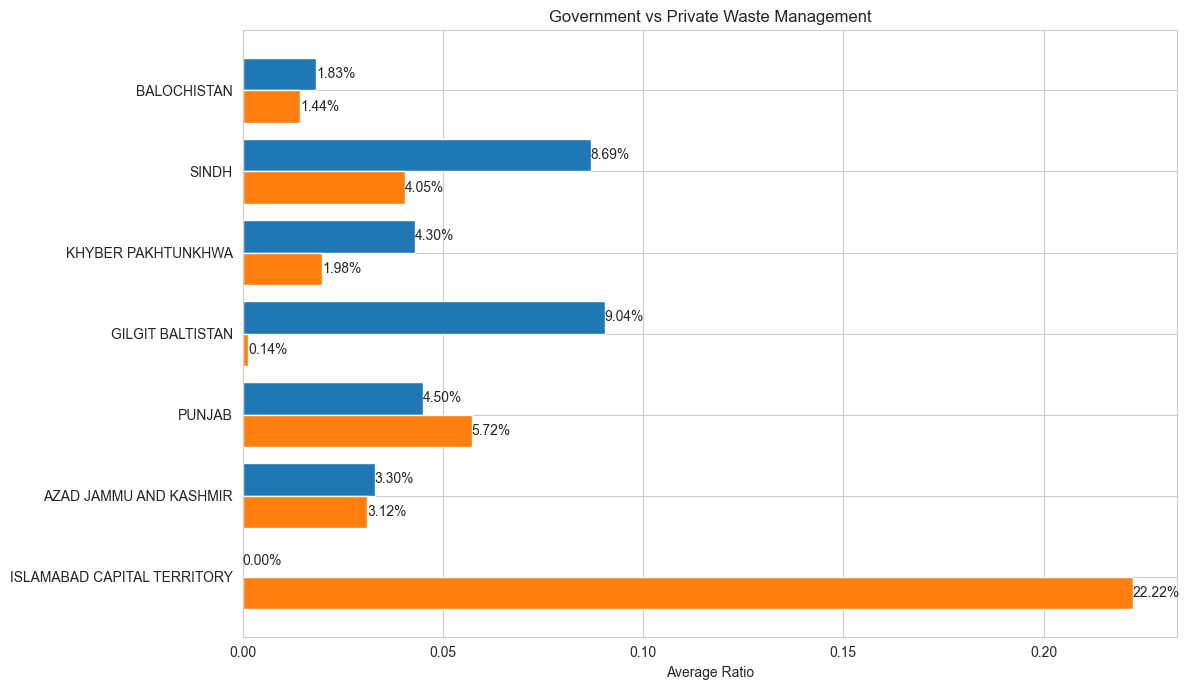

In [ ]:
# Waste Management Analysis - Provincial and District Patterns
print("="*100)
print("WASTE MANAGEMENT INFRASTRUCTURE")
print("="*100)

# Province-wise waste management
waste_cols = ['Ratio of mouzas with no waste management', 'Ratio of mouzas with any waste management',
              'Ratio of mouzas with government waste management', 'Ratio of mouzas with private waste management']
province_waste = df.groupby('Name of Province')[waste_cols].mean()

print("\nAverage Waste Management Ratios by Province:")
print(province_waste.round(4))

# District clustering by waste management
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Waste Management Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    # No waste management
    critical = (province_data['Ratio of mouzas with no waste management'] > 0.9).sum()
    high_no_waste = ((province_data['Ratio of mouzas with no waste management'] > 0.7) & 
                     (province_data['Ratio of mouzas with no waste management'] <= 0.9)).sum()
    moderate_no_waste = ((province_data['Ratio of mouzas with no waste management'] > 0.5) & 
                         (province_data['Ratio of mouzas with no waste management'] <= 0.7)).sum()
    low_no_waste = (province_data['Ratio of mouzas with no waste management'] <= 0.5).sum()
    
    print(f"  • {critical} districts: >90% mouzas have NO waste management (Critical)")
    print(f"  • {high_no_waste} districts: 70-90% mouzas have NO waste management (Very Poor)")
    print(f"  • {moderate_no_waste} districts: 50-70% mouzas have NO waste management (Poor)")
    print(f"  • {low_no_waste} districts: <50% mouzas have NO waste management (Better)")
    
    # With any waste management
    good_waste = (province_data['Ratio of mouzas with any waste management'] > 0.3).sum()
    print(f"  • {good_waste} districts: >30% mouzas have some waste management system")

# Visualization
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Waste Management Systems: Provincial Comparison', fontsize=16, fontweight='bold')

# IMPORTANT: use the same province_order you defined earlier
# Example (if not already defined above):
# province_order = df.groupby('Name of Province')['Ratio of mouzas with inside toilet facility'] \
#                    .mean().sort_values(ascending=False).index

waste_metrics = [
    ('Ratio of mouzas with no waste management', 'No Waste Management', '#E74C3C'),
    ('Ratio of mouzas with any waste management', 'Any Waste Management', '#27AE60'),
    ('Ratio of mouzas with government waste management', 'Government Waste Management', '#3498DB'),
    ('Ratio of mouzas with private waste management', 'Private Waste Management', '#9B59B6')
]

for idx, (col, title, color) in enumerate(waste_metrics):
    ax = axes[idx // 2, idx % 2]
    
    # use fixed order
    province_avg = df.groupby('Name of Province')[col].mean().loc[province_order]

    ax.barh(range(len(province_avg)), province_avg.values, color=color, alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(province_avg)))
    ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
    ax.set_xlabel('Average Ratio', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    for i, v in enumerate(province_avg.values):
        ax.text(v, i, f' {v:.2%}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

SEWERAGE AND DRAINAGE SYSTEMS

Average Cemented Drain Ratios by Province:
                             Ratio of mouzas with all cemented drains  \
Name of Province                                                        
AZAD JAMMU AND KASHMIR                                         0.0179   
BALOCHISTAN                                                    0.0087   
GILGIT BALTISTAN                                               0.0028   
ISLAMABAD CAPITAL TERRITORY                                    0.0463   
KHYBER PAKHTUNKHWA                                             0.0424   
PUNJAB                                                         0.1566   
SINDH                                                          0.0209   

                             Ratio of mouzas with mostly cemented drains  \
Name of Province                                                           
AZAD JAMMU AND KASHMIR                                            0.0658   
BALOCHISTAN                             

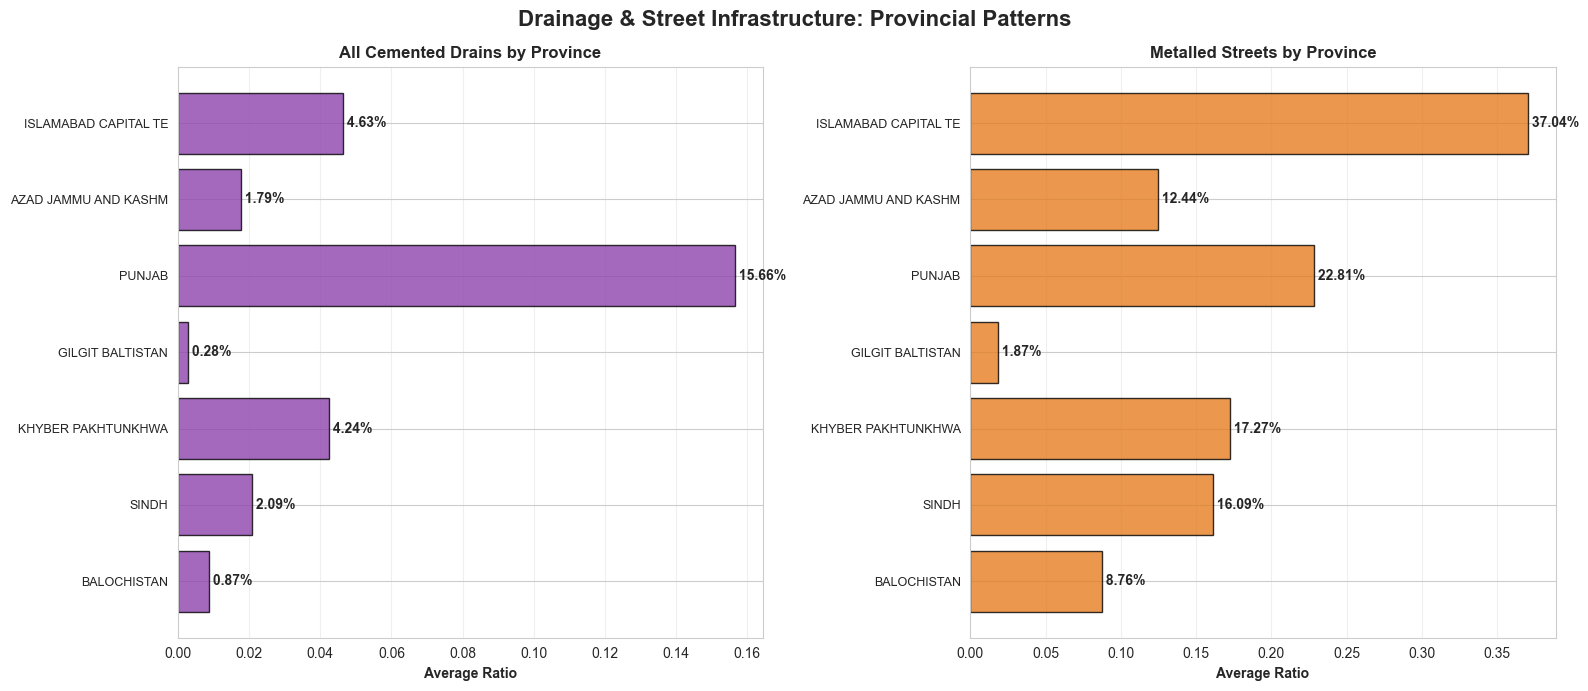

In [14]:
# Sewerage and Drainage Systems Analysis
print("="*100)
print("SEWERAGE AND DRAINAGE SYSTEMS")
print("="*100)

# Province-wise sewerage
sewerage_cols = ['Ratio of mouzas with all cemented drains', 'Ratio of mouzas with mostly cemented drains',
                 'Ratio of mouzas with some cemented drains', 'Ratio of mouzas with no cemented drains']
province_sewerage = df.groupby('Name of Province')[sewerage_cols].mean()

print("\nAverage Cemented Drain Ratios by Province:")
print(province_sewerage.round(4))

# District clustering by sewerage coverage
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Cemented Drain Coverage")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    # All cemented drains
    excellent = (province_data['Ratio of mouzas with all cemented drains'] > 0.5).sum()
    good = ((province_data['Ratio of mouzas with all cemented drains'] > 0.2) & 
            (province_data['Ratio of mouzas with all cemented drains'] <= 0.5)).sum()
    poor = (province_data['Ratio of mouzas with all cemented drains'] <= 0.2).sum()
    
    print(f"  • {excellent} districts: >50% mouzas have ALL cemented drains (Excellent)")
    print(f"  • {good} districts: 20-50% mouzas have ALL cemented drains (Good)")
    print(f"  • {poor} districts: <20% mouzas have ALL cemented drains (Poor)")
    
    # No cemented drains
    critical = (province_data['Ratio of mouzas with no cemented drains'] > 0.8).sum()
    print(f"  • {critical} districts: >80% mouzas have NO cemented drains (Critical)")

# Street types analysis
print("\n" + "="*100)
print("STREET INFRASTRUCTURE")
print("="*100)

street_cols = ['Ratio of mouzas with Metalled Streets', 'Ratio of mouzas with Cemented Streets',
               'Ratio of mouzas with Bricked Streets', 'Ratio of mouzas with Unmetalled Streets']
province_streets = df.groupby('Name of Province')[street_cols].mean()

print("\nAverage Street Type Ratios by Province:")
print(province_streets.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Drainage & Street Infrastructure: Provincial Patterns', fontsize=16, fontweight='bold')

# IMPORTANT: use same province_order that you defined earlier
# Example if not defined:
# province_order = df.groupby('Name of Province')[
#     'Ratio of mouzas with inside toilet facility'
# ].mean().sort_values(ascending=False).index

# Cemented drains
ax = axes[0]
province_avg = (
    df.groupby('Name of Province')['Ratio of mouzas with all cemented drains']
    .mean()
    .loc[province_order]
)

ax.barh(range(len(province_avg)), province_avg.values, color='#8E44AD',
        alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(province_avg)))
ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
ax.set_xlabel('Average Ratio', fontweight='bold')
ax.set_title('All Cemented Drains by Province', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, v in enumerate(province_avg.values):
    ax.text(v, i, f' {v:.2%}', va='center', fontweight='bold')

# Metalled streets
ax = axes[1]
province_avg = (
    df.groupby('Name of Province')['Ratio of mouzas with Metalled Streets']
    .mean()
    .loc[province_order]
)

ax.barh(range(len(province_avg)), province_avg.values, color='#E67E22',
        alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(province_avg)))
ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
ax.set_xlabel('Average Ratio', fontweight='bold')
ax.set_title('Metalled Streets by Province', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, v in enumerate(province_avg.values):
    ax.text(v, i, f' {v:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


DRINKING WATER INFRASTRUCTURE

Average Water Source Ratios by Province:
                             Ratio of mouzas with sweet underground water  \
Name of Province                                                            
AZAD JAMMU AND KASHMIR                                             0.9963   
BALOCHISTAN                                                        0.8171   
GILGIT BALTISTAN                                                   0.9914   
ISLAMABAD CAPITAL TERRITORY                                        0.9722   
KHYBER PAKHTUNKHWA                                                 0.9498   
PUNJAB                                                             0.8136   
SINDH                                                              0.6939   

                             Ratio of mouzas with govt piped supply for drinking water  \
Name of Province                                                                         
AZAD JAMMU AND KASHMIR                                

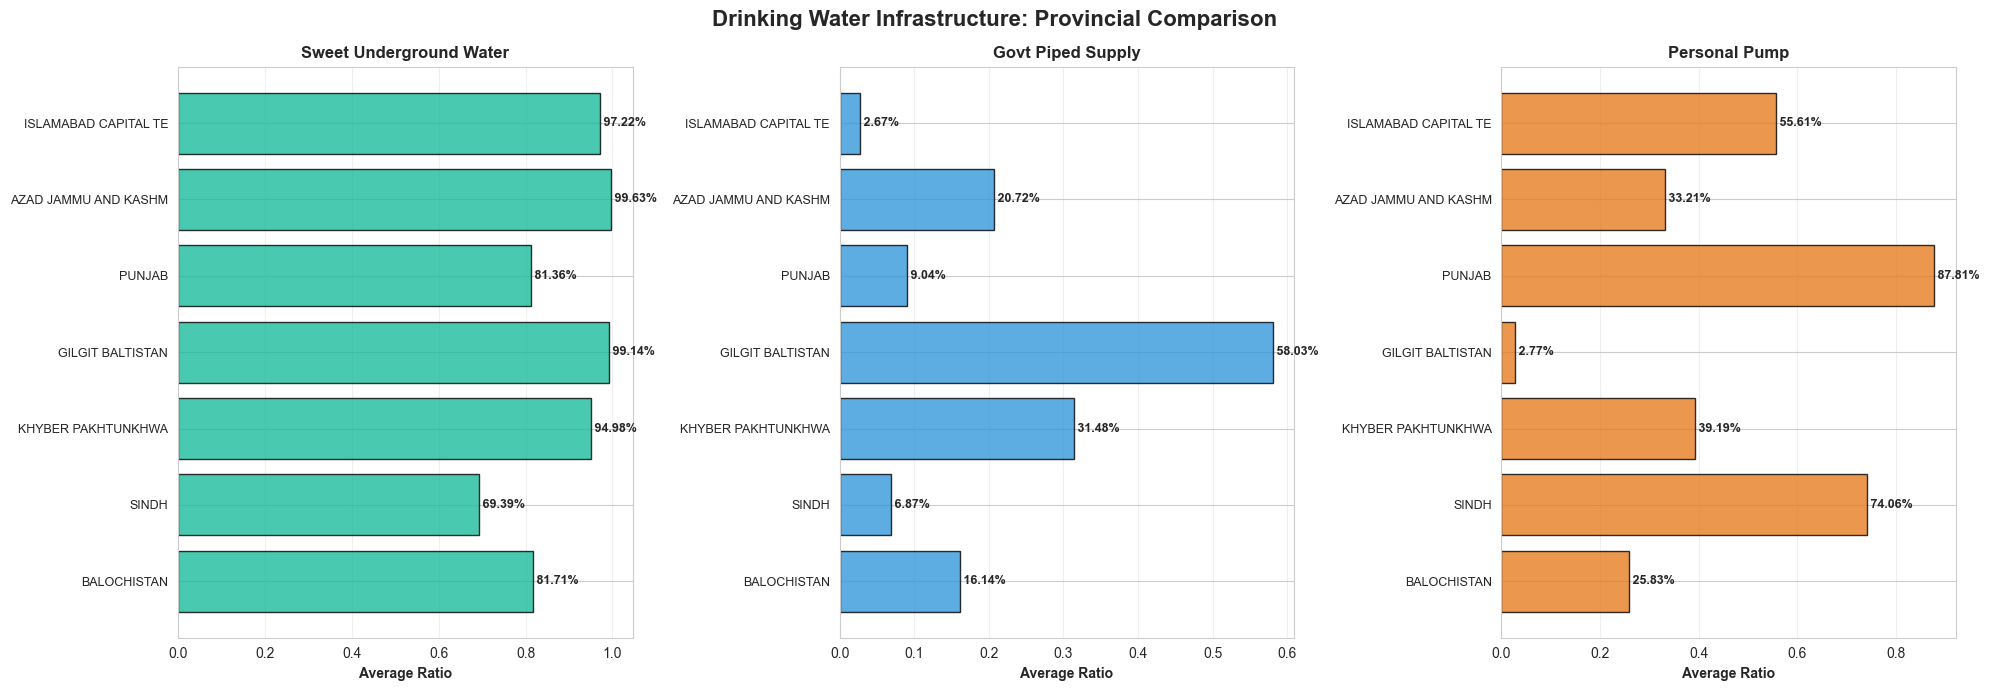

In [15]:
# Sweet Water Availability Analysis
print("="*100)
print("DRINKING WATER INFRASTRUCTURE")
print("="*100)

# Province-wise water availability
water_cols = ['Ratio of mouzas with sweet underground water', 
              'Ratio of mouzas with govt piped supply for drinking water',
              'Ratio of mouzas with personal hand/electric pump for drinking water']
province_water = df.groupby('Name of Province')[water_cols].mean()

print("\nAverage Water Source Ratios by Province:")
print(province_water.round(4))

# District clustering by sweet underground water
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Sweet Underground Water Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    excellent = (province_data['Ratio of mouzas with sweet underground water'] > 0.9).sum()
    good = ((province_data['Ratio of mouzas with sweet underground water'] > 0.7) & 
            (province_data['Ratio of mouzas with sweet underground water'] <= 0.9)).sum()
    moderate = ((province_data['Ratio of mouzas with sweet underground water'] > 0.5) & 
                (province_data['Ratio of mouzas with sweet underground water'] <= 0.7)).sum()
    poor = (province_data['Ratio of mouzas with sweet underground water'] <= 0.5).sum()
    
    print(f"  • {excellent} districts: >90% mouzas have sweet underground water (Excellent)")
    print(f"  • {good} districts: 70-90% mouzas have sweet underground water (Good)")
    print(f"  • {moderate} districts: 50-70% mouzas have sweet underground water (Moderate)")
    print(f"  • {poor} districts: <50% mouzas have sweet underground water (Poor)")
    
    # Piped water supply
    piped_water = (province_data['Ratio of mouzas with govt piped supply for drinking water'] > 0.3).sum()
    print(f"  • {piped_water} districts: >30% mouzas have government piped water supply")


    # ----- Visualization -----
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Drinking Water Infrastructure: Provincial Comparison',
             fontsize=16, fontweight='bold')

water_metrics = [
    ('Ratio of mouzas with sweet underground water', 'Sweet Underground Water', '#1ABC9C'),
    ('Ratio of mouzas with govt piped supply for drinking water', 'Govt Piped Supply', '#3498DB'),
    ('Ratio of mouzas with personal hand/electric pump for drinking water', 'Personal Pump', '#E67E22')
]

for idx, (col, title, color) in enumerate(water_metrics):
    ax = axes[idx]
    
    province_avg = (
        df.groupby('Name of Province')[col]
        .mean()
        .loc[province_order]      # <-- key line (keeps same order)
    )
    
    ax.barh(range(len(province_avg)), province_avg.values,
            color=color, alpha=0.8, edgecolor='black')
    
    ax.set_yticks(range(len(province_avg)))
    ax.set_yticklabels([p[:20] for p in province_avg.index], fontsize=9)
    ax.set_xlabel('Average Ratio', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    for i, v in enumerate(province_avg.values):
        ax.text(v, i, f' {v:.2%}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Part 2: Education & Sports Analysis
### Focus: Provincial Access Patterns and District-Level Distribution

In [16]:
# Boys Education Infrastructure - Provincial Patterns
print("="*100)
print("BOYS EDUCATION INFRASTRUCTURE: Availability Patterns by Province")
print("="*100)

# Province-wise boys education
boys_edu_cols = ['Ratio of mouzas having Boys Primary School', 
                 'Ratio of mouzas having Boys Middle School',
                 'Ratio of mouzas having Boys High/Higher Secondary School',
                 'Ratio of mouzas having Boys College']
province_boys_edu = df.groupby('Name of Province')[boys_edu_cols].mean()

print("\nAverage Boys Education Ratios by Province:")
print(province_boys_edu.round(4))

# District clustering for Boys Primary Schools
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Boys Primary School Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    excellent = (province_data['Ratio of mouzas having Boys Primary School'] > 0.9).sum()
    good = ((province_data['Ratio of mouzas having Boys Primary School'] > 0.7) & 
            (province_data['Ratio of mouzas having Boys Primary School'] <= 0.9)).sum()
    moderate = ((province_data['Ratio of mouzas having Boys Primary School'] > 0.5) & 
                (province_data['Ratio of mouzas having Boys Primary School'] <= 0.7)).sum()
    poor = (province_data['Ratio of mouzas having Boys Primary School'] <= 0.5).sum()
    
    print(f"  • {excellent} districts: >90% mouzas have Boys Primary Schools (Excellent)")
    print(f"  • {good} districts: 70-90% mouzas have Boys Primary Schools (Good)")
    print(f"  • {moderate} districts: 50-70% mouzas have Boys Primary Schools (Moderate)")
    print(f"  • {poor} districts: <50% mouzas have Boys Primary Schools (Critical)")
    
    # High schools
    high_school_good = (province_data['Ratio of mouzas having Boys High/Higher Secondary School'] > 0.3).sum()
    print(f"  • {high_school_good} districts: >30% mouzas have Boys High/Higher Secondary Schools")
    
    # Colleges
    college_available = (province_data['Ratio of mouzas having Boys College'] > 0.05).sum()
    print(f"  • {college_available} districts: >5% mouzas have Boys Colleges")

BOYS EDUCATION INFRASTRUCTURE: Availability Patterns by Province

Average Boys Education Ratios by Province:
                             Ratio of mouzas having Boys Primary School  \
Name of Province                                                          
AZAD JAMMU AND KASHMIR                                           0.8634   
BALOCHISTAN                                                      0.7190   
GILGIT BALTISTAN                                                 0.9070   
ISLAMABAD CAPITAL TERRITORY                                      0.7593   
KHYBER PAKHTUNKHWA                                               0.8114   
PUNJAB                                                           0.8299   
SINDH                                                            0.9039   

                             Ratio of mouzas having Boys Middle School  \
Name of Province                                                         
AZAD JAMMU AND KASHMIR                                          0.5

<Figure size 1200x600 with 0 Axes>

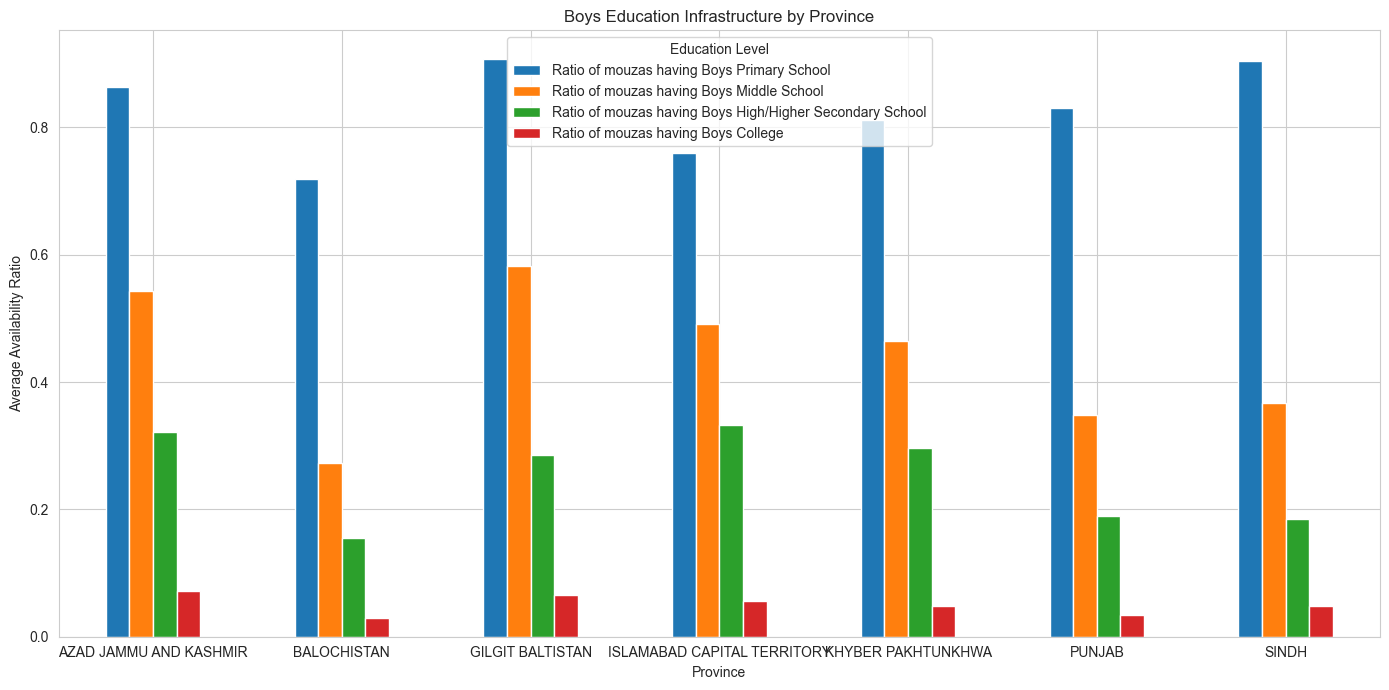

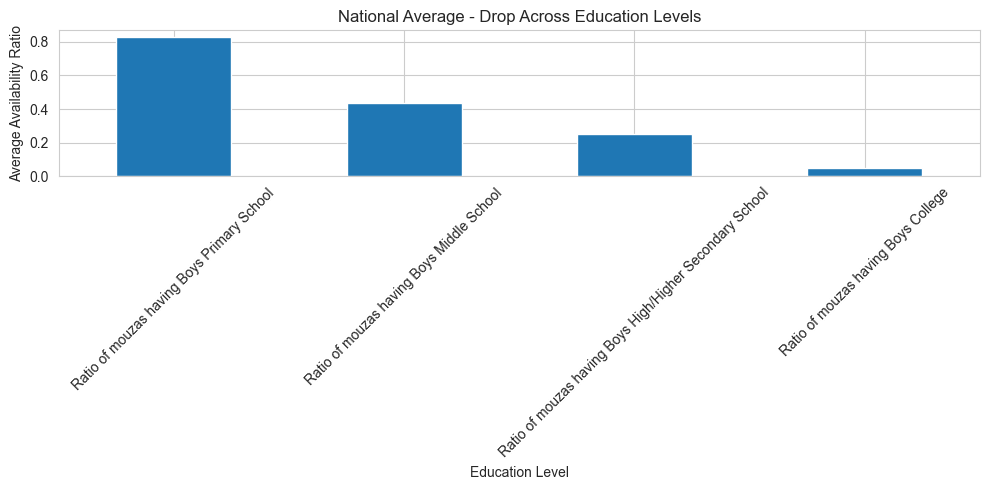

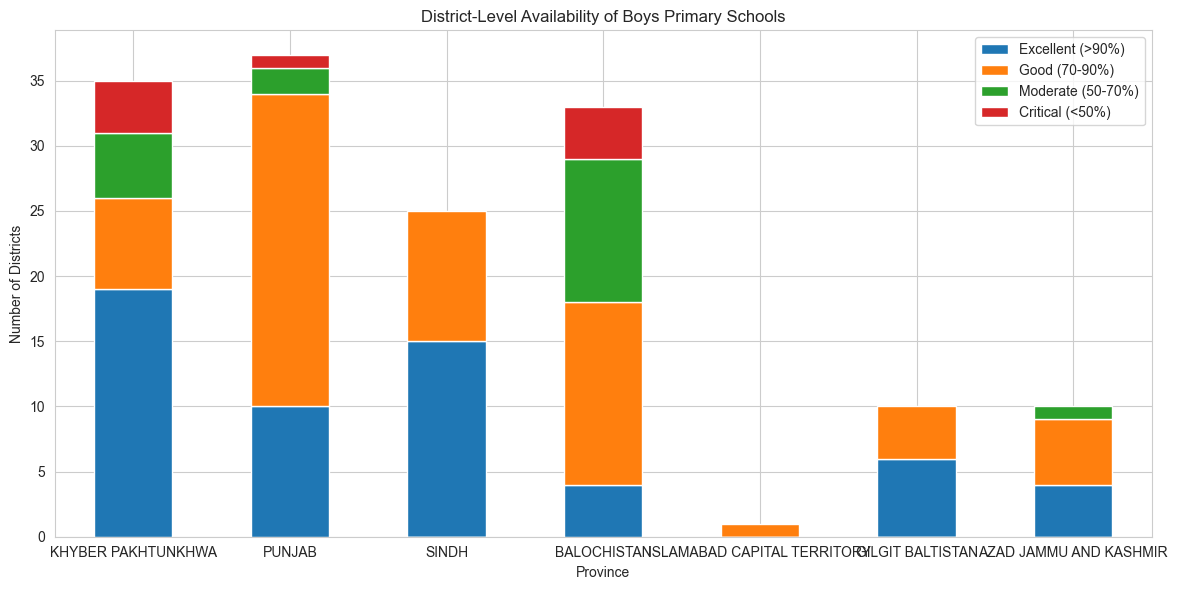

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
province_boys_edu.plot(kind='bar')
plt.title("Boys Education Infrastructure by Province")
plt.ylabel("Average Availability Ratio")
plt.xlabel("Province")
plt.xticks(rotation=0)
plt.legend(title="Education Level")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
province_boys_edu.mean().plot(kind='bar')
plt.title("National Average - Drop Across Education Levels")
plt.ylabel("Average Availability Ratio")
plt.xlabel("Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


district_clusters = []

for prov in df['Name of Province'].unique():
    pr = df[df['Name of Province'] == prov]['Ratio of mouzas having Boys Primary School']
    
    district_clusters.append({
        "Province": prov,
        "Excellent (>90%)": (pr > 0.9).sum(),
        "Good (70-90%)": ((pr>0.7) & (pr<=0.9)).sum(),
        "Moderate (50-70%)": ((pr>0.5) & (pr<=0.7)).sum(),
        "Critical (<50%)": (pr<=0.5).sum(),
    })

cluster_df = pd.DataFrame(district_clusters).set_index('Province')

cluster_df.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("District-Level Availability of Boys Primary Schools")
plt.ylabel("Number of Districts")
plt.xlabel("Province")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [18]:
# Girls Education Infrastructure - Provincial Patterns
print("="*100)
print("GIRLS EDUCATION INFRASTRUCTURE: Availability Patterns by Province")
print("="*100)

# Province-wise girls education
girls_edu_cols = ['Ratio of mouzas having Girls Primary School', 
                  'Ratio of mouzas having Girls Middle School',
                  'Ratio of mouzas having Girls High/Higher Secondary School',
                  'Ratio of mouzas having Girls College']
province_girls_edu = df.groupby('Name of Province')[girls_edu_cols].mean()

print("\nAverage Girls Education Ratios by Province:")
print(province_girls_edu.round(4))

# District clustering for Girls Primary Schools
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Girls Primary School Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    excellent = (province_data['Ratio of mouzas having Girls Primary School'] > 0.8).sum()
    good = ((province_data['Ratio of mouzas having Girls Primary School'] > 0.6) & 
            (province_data['Ratio of mouzas having Girls Primary School'] <= 0.8)).sum()
    moderate = ((province_data['Ratio of mouzas having Girls Primary School'] > 0.4) & 
                (province_data['Ratio of mouzas having Girls Primary School'] <= 0.6)).sum()
    poor = (province_data['Ratio of mouzas having Girls Primary School'] <= 0.4).sum()
    
    print(f"  • {excellent} districts: >80% mouzas have Girls Primary Schools (Excellent)")
    print(f"  • {good} districts: 60-80% mouzas have Girls Primary Schools (Good)")
    print(f"  • {moderate} districts: 40-60% mouzas have Girls Primary Schools (Moderate)")
    print(f"  • {poor} districts: <40% mouzas have Girls Primary Schools (Critical)")

# Gender Gap Analysis
print("\n" + "="*100)
print("GENDER GAP IN EDUCATION: Provincial Comparison")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    
    boys_primary = province_data['Ratio of mouzas having Boys Primary School'].mean()
    girls_primary = province_data['Ratio of mouzas having Girls Primary School'].mean()
    primary_gap = boys_primary - girls_primary
    
    boys_high = province_data['Ratio of mouzas having Boys High/Higher Secondary School'].mean()
    girls_high = province_data['Ratio of mouzas having Girls High/Higher Secondary School'].mean()
    high_gap = boys_high - girls_high
    
    print(f"\n{province}:")
    print(f"  Primary School Gap: {primary_gap:+.2%} (Boys: {boys_primary:.2%}, Girls: {girls_primary:.2%})")
    print(f"  High School Gap: {high_gap:+.2%} (Boys: {boys_high:.2%}, Girls: {girls_high:.2%})")
    
    # Count districts with significant gap
    significant_gap = (province_data['Ratio of mouzas having Boys Primary School'] - 
                      province_data['Ratio of mouzas having Girls Primary School'] > 0.2).sum()
    print(f"  {significant_gap} districts have >20% gender gap in primary education")

GIRLS EDUCATION INFRASTRUCTURE: Availability Patterns by Province

Average Girls Education Ratios by Province:
                             Ratio of mouzas having Girls Primary School  \
Name of Province                                                           
AZAD JAMMU AND KASHMIR                                            0.8242   
BALOCHISTAN                                                       0.4325   
GILGIT BALTISTAN                                                  0.8221   
ISLAMABAD CAPITAL TERRITORY                                       0.7037   
KHYBER PAKHTUNKHWA                                                0.6629   
PUNJAB                                                            0.7710   
SINDH                                                             0.6587   

                             Ratio of mouzas having Girls Middle School  \
Name of Province                                                          
AZAD JAMMU AND KASHMIR                                

<Figure size 1200x600 with 0 Axes>

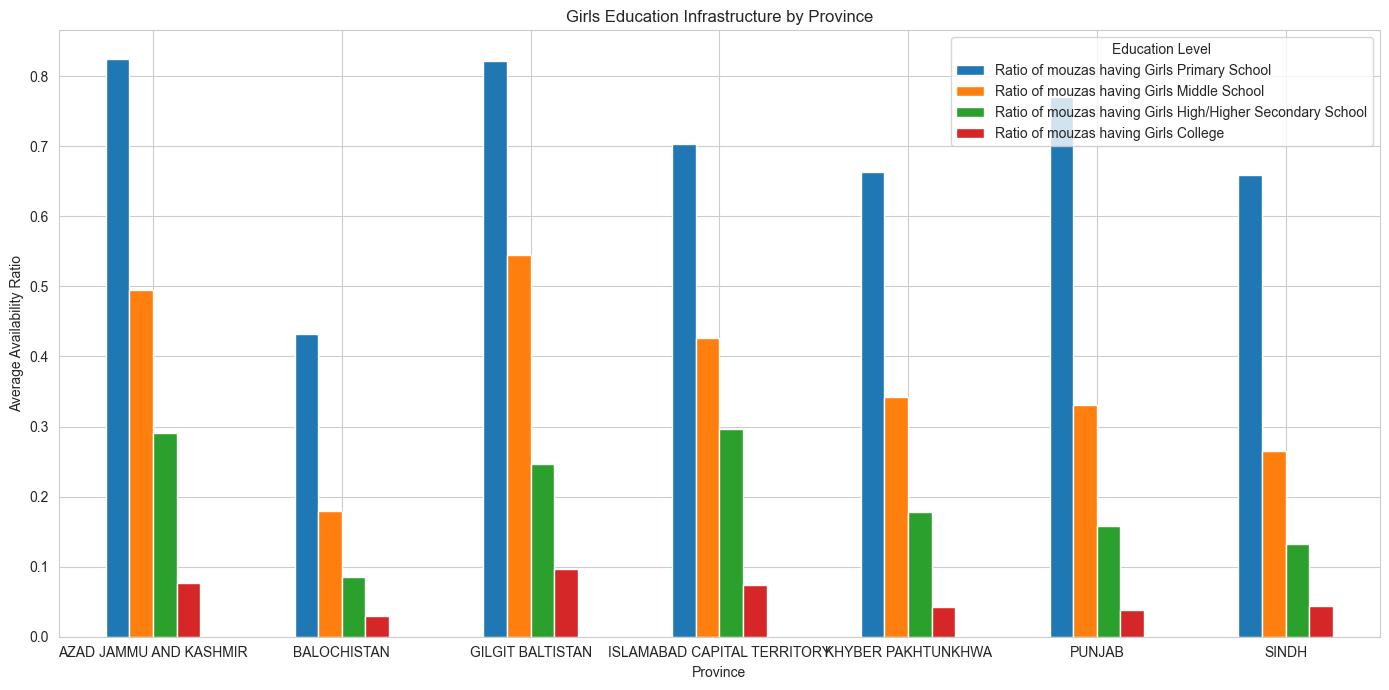

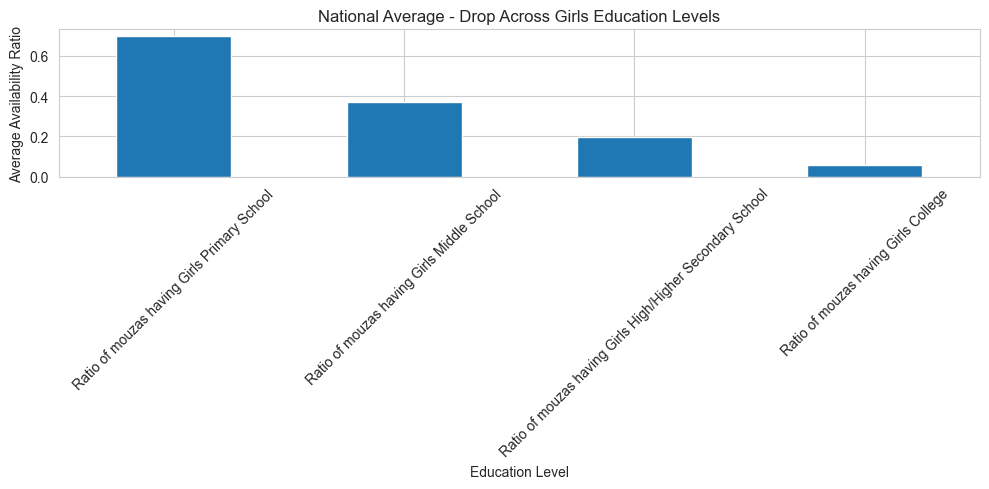

<Figure size 1200x600 with 0 Axes>

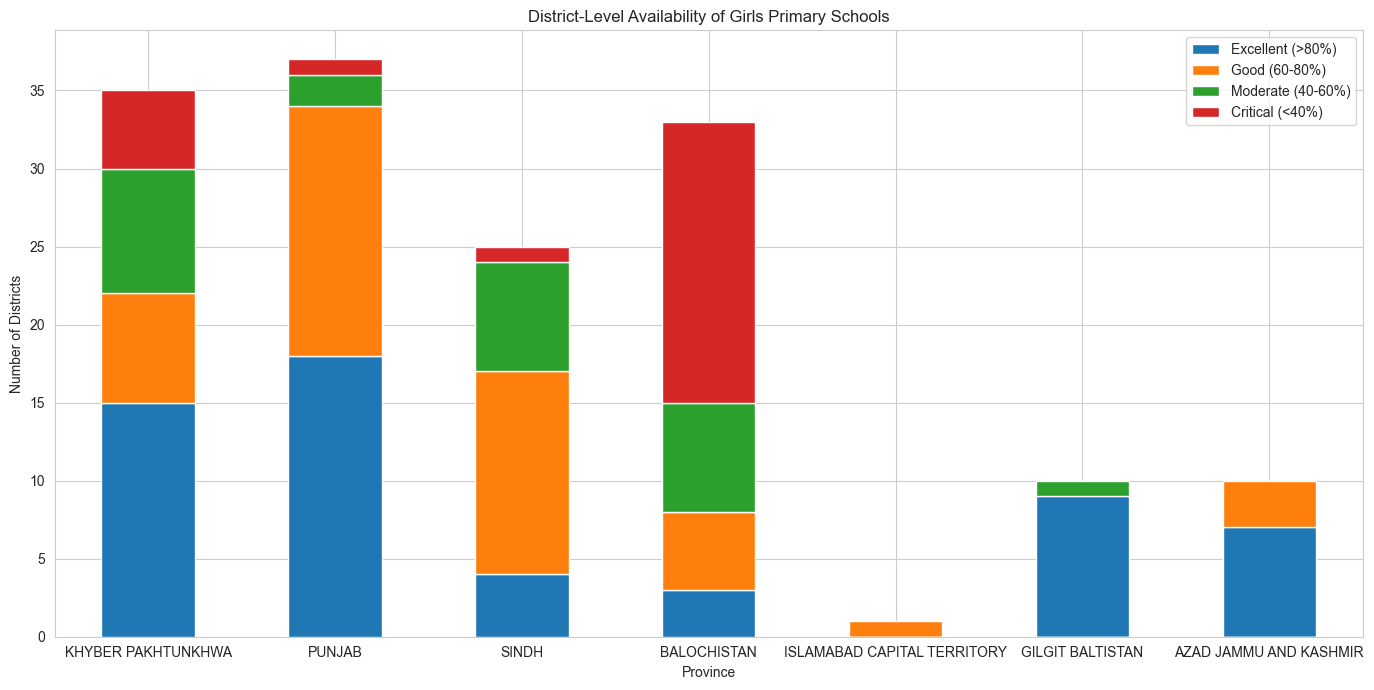

In [19]:
# 1. Province-wise Girls Education (grouped bar)

plt.figure(figsize=(12,6))
province_girls_edu.plot(kind='bar')
plt.title("Girls Education Infrastructure by Province")
plt.ylabel("Average Availability Ratio")
plt.xlabel("Province")
plt.xticks(rotation=0)
plt.legend(title="Education Level")
plt.tight_layout()
plt.show()


# 2. National drop by education level (Primary → Middle → High → College)
plt.figure(figsize=(10,5))
province_girls_edu.mean().plot(kind='bar')
plt.title("National Average - Drop Across Girls Education Levels")
plt.ylabel("Average Availability Ratio")
plt.xlabel("Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. District category distribution (stacked bars)
girls_clusters = []

for prov in df['Name of Province'].unique():
    pr = df[df['Name of Province'] == prov]['Ratio of mouzas having Girls Primary School']
    
    girls_clusters.append({
        "Province": prov,
        "Excellent (>80%)": (pr > 0.8).sum(),
        "Good (60-80%)": ((pr>0.6) & (pr<=0.8)).sum(),
        "Moderate (40-60%)": ((pr>0.4) & (pr<=0.6)).sum(),
        "Critical (<40%)": (pr<=0.4).sum(),
    })

girls_cluster_df = pd.DataFrame(girls_clusters).set_index('Province')

plt.figure(figsize=(12,6))
girls_cluster_df.plot(kind='bar', stacked=True)
plt.title("District-Level Availability of Girls Primary Schools")
plt.ylabel("Number of Districts")
plt.xlabel("Province")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


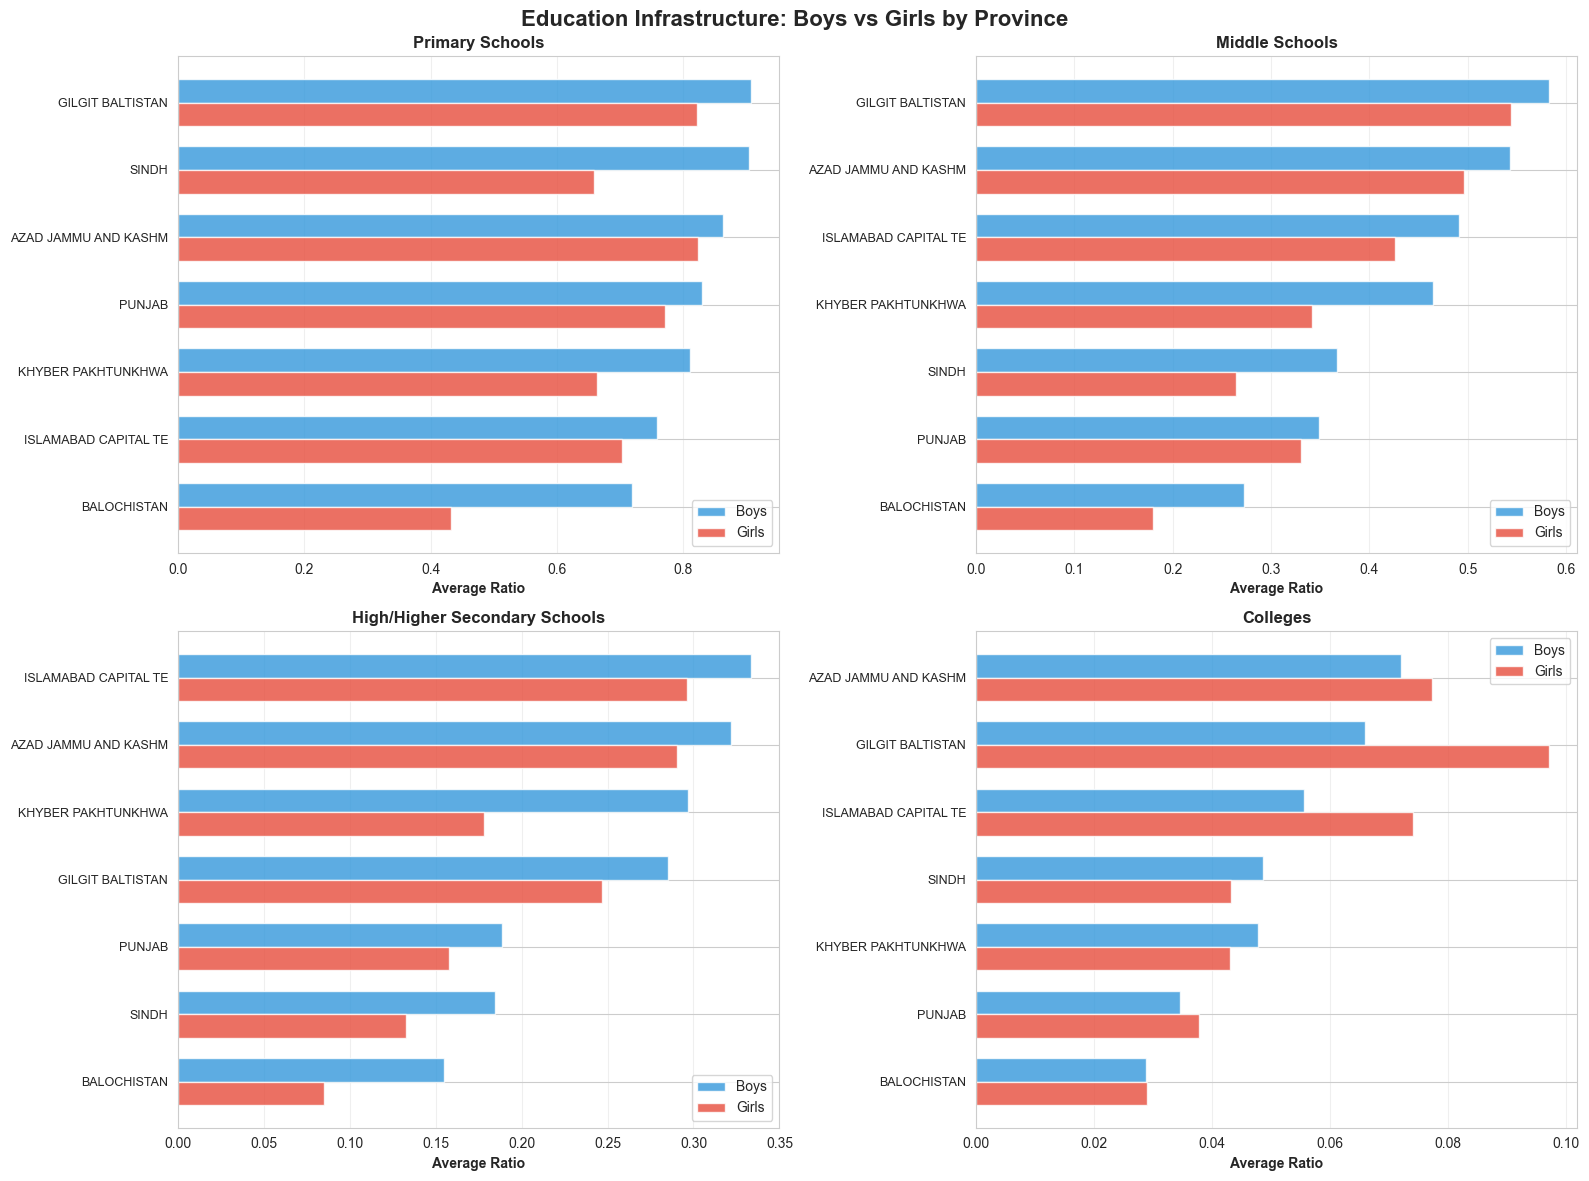

In [20]:
# Visualize Education Infrastructure - Boys vs Girls by Province
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Education Infrastructure: Boys vs Girls by Province', fontsize=16, fontweight='bold')

education_levels = [
    ('Ratio of mouzas having Boys Primary School', 'Ratio of mouzas having Girls Primary School', 'Primary Schools'),
    ('Ratio of mouzas having Boys Middle School', 'Ratio of mouzas having Girls Middle School', 'Middle Schools'),
    ('Ratio of mouzas having Boys High/Higher Secondary School', 'Ratio of mouzas having Girls High/Higher Secondary School', 'High/Higher Secondary Schools'),
    ('Ratio of mouzas having Boys College', 'Ratio of mouzas having Girls College', 'Colleges')
]

for idx, (boys_col, girls_col, title) in enumerate(education_levels):
    ax = axes[idx // 2, idx % 2]
    
    province_data = df.groupby('Name of Province')[[boys_col, girls_col]].mean().sort_values(boys_col, ascending=False)
    
    x = np.arange(len(province_data))
    width = 0.35
    
    ax.barh(x - width/2, province_data[boys_col], width, label='Boys', color='#3498DB', alpha=0.8)
    ax.barh(x + width/2, province_data[girls_col], width, label='Girls', color='#E74C3C', alpha=0.8)
    
    ax.set_yticks(x)
    ax.set_yticklabels([p[:20] for p in province_data.index], fontsize=9)
    ax.set_xlabel('Average Ratio', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:
# Sports Facilities Analysis - Provincial Patterns
print("="*100)
print("SPORTS FACILITIES: Male vs Female Infrastructure by Province")
print("="*100)

# Province-wise sports facilities
sports_cols = ['Ratio of mouzas having Male Cricket Playground', 
               'Ratio of mouzas having Female Cricket Playground',
               'Ratio of mouzas having no male playground',
               'Ratio of mouzas having no female playground']
province_sports = df.groupby('Name of Province')[sports_cols].mean()

print("\nAverage Sports Facility Ratios by Province:")
print(province_sports.round(4))

# District clustering for Male Sports Facilities
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Male Sports Playground Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    # Male cricket facilities
    good_cricket = (province_data['Ratio of mouzas having Male Cricket Playground'] > 0.1).sum()
    some_cricket = ((province_data['Ratio of mouzas having Male Cricket Playground'] > 0.05) & 
                   (province_data['Ratio of mouzas having Male Cricket Playground'] <= 0.1)).sum()
    little_cricket = (province_data['Ratio of mouzas having Male Cricket Playground'] <= 0.05).sum()
    
    print(f"  • {good_cricket} districts: >10% mouzas have male cricket playgrounds (Good)")
    print(f"  • {some_cricket} districts: 5-10% mouzas have male cricket playgrounds (Moderate)")
    print(f"  • {little_cricket} districts: <5% mouzas have male cricket playgrounds (Poor)")
    
    # No male sports facilities
    critical = (province_data['Ratio of mouzas having no male playground'] > 0.9).sum()
    print(f"  • {critical} districts: >90% mouzas have NO male sports facilities (Critical)")

# Female sports facilities clustering
print("\n" + "="*100)
print("DISTRICT CLUSTERING: Female Sports Playground Availability")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total_districts = len(province_data)
    
    print(f"\n{province.upper()} ({total_districts} districts):")
    
    # Female sports facilities
    any_facilities = (province_data['Ratio of mouzas having no female playground'] < 1.0).sum()
    no_facilities = (province_data['Ratio of mouzas having no female playground'] >= 1.0).sum()
    
    print(f"  • {any_facilities} districts: Have SOME female sports facilities")
    print(f"  • {no_facilities} districts: Have NO female sports facilities at all (Critical)")
    
    # Female cricket
    female_cricket = (province_data['Ratio of mouzas having Female Cricket Playground'] > 0.01).sum()
    print(f"  • {female_cricket} districts: >1% mouzas have female cricket playgrounds")

# Gender gap in sports
print("\n" + "="*100)
print("GENDER GAP IN SPORTS: Provinces Comparison")
print("="*100)

for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    
    male_no_sports = province_data['Ratio of mouzas having no male playground'].mean()
    female_no_sports = province_data['Ratio of mouzas having no female playground'].mean()
    gap = female_no_sports - male_no_sports
    
    print(f"\n{province}:")
    print(f"  Males with no facilities: {male_no_sports:.2%}")
    print(f"  Females with no facilities: {female_no_sports:.2%}")
    print(f"  Gap (more females without facilities): {gap:+.2%}")

SPORTS FACILITIES: Male vs Female Infrastructure by Province

Average Sports Facility Ratios by Province:
                             Ratio of mouzas having Male Cricket Playground  \
Name of Province                                                              
AZAD JAMMU AND KASHMIR                                               0.0801   
BALOCHISTAN                                                          0.1212   
GILGIT BALTISTAN                                                     0.1036   
ISLAMABAD CAPITAL TERRITORY                                          0.0370   
KHYBER PAKHTUNKHWA                                                   0.0891   
PUNJAB                                                               0.0919   
SINDH                                                                0.0629   

                             Ratio of mouzas having Female Cricket Playground  \
Name of Province                                                                
AZAD JAMMU AND KASHM

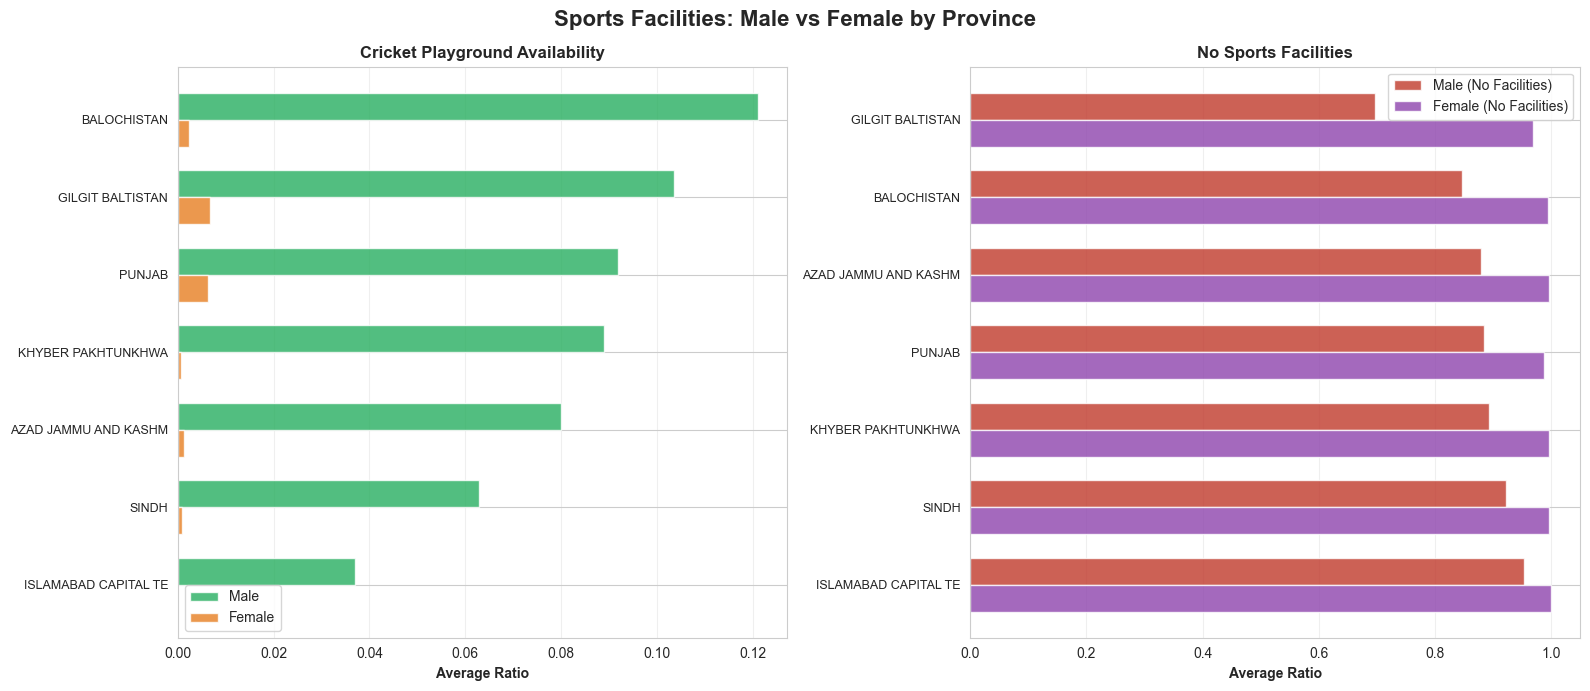

In [22]:
# Visualize Sports Facilities Gender Gap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Sports Facilities: Male vs Female by Province', fontsize=16, fontweight='bold')

# Cricket playgrounds
ax = axes[0]
province_data = df.groupby('Name of Province')[['Ratio of mouzas having Male Cricket Playground', 
                                                  'Ratio of mouzas having Female Cricket Playground']].mean().sort_values(
                                                      'Ratio of mouzas having Male Cricket Playground', ascending=False)

x = np.arange(len(province_data))
width = 0.35

ax.barh(x - width/2, province_data['Ratio of mouzas having Male Cricket Playground'], width, 
        label='Male', color='#27AE60', alpha=0.8)
ax.barh(x + width/2, province_data['Ratio of mouzas having Female Cricket Playground'], width, 
        label='Female', color='#E67E22', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels([p[:20] for p in province_data.index], fontsize=9)
ax.set_xlabel('Average Ratio', fontweight='bold')
ax.set_title('Cricket Playground Availability', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# No sports facilities
ax = axes[1]
province_data = df.groupby('Name of Province')[['Ratio of mouzas having no male playground', 
                                                  'Ratio of mouzas having no female playground']].mean().sort_values(
                                                      'Ratio of mouzas having no male playground', ascending=True)

x = np.arange(len(province_data))
ax.barh(x - width/2, province_data['Ratio of mouzas having no male playground'], width, 
        label='Male (No Facilities)', color='#C0392B', alpha=0.8)
ax.barh(x + width/2, province_data['Ratio of mouzas having no female playground'], width, 
        label='Female (No Facilities)', color='#8E44AD', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels([p[:20] for p in province_data.index], fontsize=9)
ax.set_xlabel('Average Ratio', fontweight='bold')
ax.set_title('No Sports Facilities', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## Part 3: Comprehensive Provincial Summary
### Infrastructure Score & District Performance Rankings

COMPOSITE INFRASTRUCTURE SCORES BY PROVINCE

Provincial Infrastructure Scores (0-1 scale, higher is better):
                             Housing_Score  Sanitation_Score  Education_Score  \
Name of Province                                                                
ISLAMABAD CAPITAL TERRITORY         0.9028            0.1343           0.5231   
PUNJAB                              0.7284            0.1294           0.4868   
AZAD JAMMU AND KASHMIR              0.6250            0.0410           0.5750   
GILGIT BALTISTAN                    0.4673            0.0473           0.5653   
KHYBER PAKHTUNKHWA                  0.4349            0.0526           0.4873   
SINDH                               0.3863            0.0742           0.4700   
BALOCHISTAN                         0.1654            0.0207           0.3479   

                             Sports_Score  Overall_Score  
Name of Province                                          
ISLAMABAD CAPITAL TERRITORY        0.0231  

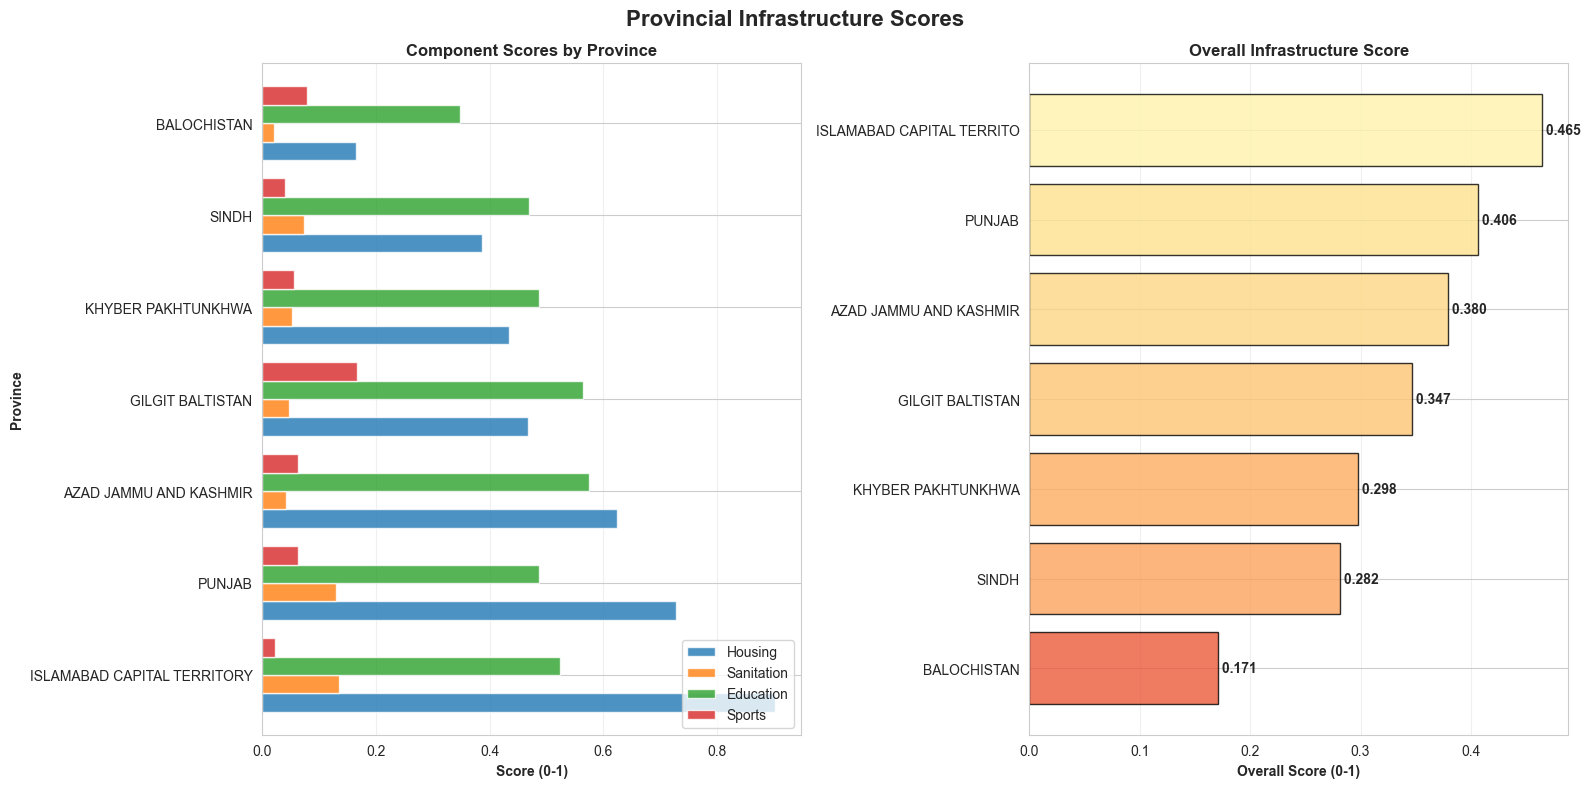

In [23]:
# Create Composite Infrastructure Scores
print("="*100)
print("COMPOSITE INFRASTRUCTURE SCORES BY PROVINCE")
print("="*100)

# Calculate composite scores
province_scores = pd.DataFrame()

# Housing score (Pucca houses + Inside toilets) / 2
province_scores['Housing_Score'] = (
    df.groupby('Name of Province')['Ratio of mouzas with Pucca houses'].mean() +
    df.groupby('Name of Province')['Ratio of mouzas with inside toilet facility'].mean()
) / 2

# Sanitation score (Any waste management + All cemented drains) / 2
province_scores['Sanitation_Score'] = (
    df.groupby('Name of Province')['Ratio of mouzas with any waste management'].mean() +
    df.groupby('Name of Province')['Ratio of mouzas with all cemented drains'].mean()
) / 2

# Education score (Boys primary + Girls primary + Boys high + Girls high) / 4
province_scores['Education_Score'] = (
    df.groupby('Name of Province')['Ratio of mouzas having Boys Primary School'].mean() +
    df.groupby('Name of Province')['Ratio of mouzas having Girls Primary School'].mean() +
    df.groupby('Name of Province')['Ratio of mouzas having Boys High/Higher Secondary School'].mean() +
    df.groupby('Name of Province')['Ratio of mouzas having Girls High/Higher Secondary School'].mean()
) / 4

# Sports score (1 - average no facilities for both genders)
province_scores['Sports_Score'] = 1 - (
    df.groupby('Name of Province')['Ratio of mouzas having no male playground'].mean() +
    df.groupby('Name of Province')['Ratio of mouzas having no female playground'].mean()
) / 2

# Overall score
province_scores['Overall_Score'] = (
    province_scores['Housing_Score'] * 0.3 +
    province_scores['Sanitation_Score'] * 0.25 +
    province_scores['Education_Score'] * 0.3 +
    province_scores['Sports_Score'] * 0.15
)

province_scores = province_scores.sort_values('Overall_Score', ascending=False)

print("\nProvincial Infrastructure Scores (0-1 scale, higher is better):")
print(province_scores.round(4))

# Visualize scores
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Provincial Infrastructure Scores', fontsize=16, fontweight='bold')

# Individual scores
ax = axes[0]
province_scores_plot = province_scores[['Housing_Score', 'Sanitation_Score', 'Education_Score', 'Sports_Score']]
province_scores_plot.plot(kind='barh', ax=ax, alpha=0.8, width=0.8)
ax.set_xlabel('Score (0-1)', fontweight='bold')
ax.set_ylabel('Province', fontweight='bold')
ax.set_title('Component Scores by Province', fontweight='bold')
ax.legend(['Housing', 'Sanitation', 'Education', 'Sports'], loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Overall score
ax = axes[1]
colors = plt.cm.RdYlGn(province_scores['Overall_Score'])
ax.barh(range(len(province_scores)), province_scores['Overall_Score'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(province_scores)))
ax.set_yticklabels([p[:25] for p in province_scores.index], fontsize=10)
ax.set_xlabel('Overall Score (0-1)', fontweight='bold')
ax.set_title('Overall Infrastructure Score', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, v in enumerate(province_scores['Overall_Score']):
    ax.text(v, i, f' {v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
# Top and Bottom Performing Districts Analysis
print("="*100)
print("TOP AND BOTTOM PERFORMING DISTRICTS ACROSS ALL PROVINCES")
print("="*100)

# Calculate district scores
district_scores = pd.DataFrame()
district_scores['District'] = df['Name of District']
district_scores['Province'] = df['Name of Province']

district_scores['Housing_Score'] = (
    df['Ratio of mouzas with Pucca houses'] +
    df['Ratio of mouzas with inside toilet facility']
) / 2

district_scores['Sanitation_Score'] = (
    df['Ratio of mouzas with any waste management'] +
    df['Ratio of mouzas with all cemented drains']
) / 2

district_scores['Education_Score'] = (
    df['Ratio of mouzas having Boys Primary School'] +
    df['Ratio of mouzas having Girls Primary School'] +
    df['Ratio of mouzas having Boys High/Higher Secondary School'] +
    df['Ratio of mouzas having Girls High/Higher Secondary School']
) / 4

district_scores['Sports_Score'] = 1 - (
    df['Ratio of mouzas having no male playground'] +
    df['Ratio of mouzas having no female playground']
) / 2

district_scores['Overall_Score'] = (
    district_scores['Housing_Score'] * 0.3 +
    district_scores['Sanitation_Score'] * 0.25 +
    district_scores['Education_Score'] * 0.3 +
    district_scores['Sports_Score'] * 0.15
)

# Top 15 districts
print("\nTOP 15 DISTRICTS (Overall Infrastructure Score):")
top_15 = district_scores.nlargest(15, 'Overall_Score')[['District', 'Province', 'Overall_Score', 
                                                          'Housing_Score', 'Sanitation_Score', 
                                                          'Education_Score', 'Sports_Score']]
print(top_15.to_string(index=False))

# Bottom 15 districts
print("\n\nBOTTOM 15 DISTRICTS (Overall Infrastructure Score):")
bottom_15 = district_scores.nsmallest(15, 'Overall_Score')[['District', 'Province', 'Overall_Score', 
                                                              'Housing_Score', 'Sanitation_Score', 
                                                              'Education_Score', 'Sports_Score']]
print(bottom_15.to_string(index=False))

# Provincial distribution of top districts
print("\n" + "="*100)
print("PROVINCE-WISE DISTRIBUTION OF TOP 30 DISTRICTS")
print("="*100)

top_30 = district_scores.nlargest(30, 'Overall_Score')
province_top_dist = top_30['Province'].value_counts()
print(province_top_dist)

TOP AND BOTTOM PERFORMING DISTRICTS ACROSS ALL PROVINCES

TOP 15 DISTRICTS (Overall Infrastructure Score):
                District                    Province  Overall_Score  Housing_Score  Sanitation_Score  Education_Score  Sports_Score
         LAHORE DISTRICT                      PUNJAB       0.608547       0.952991          0.500000         0.610399      0.096866
     FAISALABAD DISTRICT                      PUNJAB       0.550239       0.900120          0.264952         0.609450      0.207536
     GUJRANWALA DISTRICT                      PUNJAB       0.536525       0.960025          0.292128         0.548705      0.072494
         GUJRAT DISTRICT                      PUNJAB       0.530687       0.961393          0.347140         0.508902      0.018757
 TOBA TEK SINGH DISTRICT                      PUNJAB       0.527952       0.904059          0.184502         0.542897      0.318266
        SIALKOT DISTRICT                      PUNJAB       0.521614       0.964431          0.323455 

In [25]:
# Key Insights Summary - Province and District Behavior
print("="*100)
print("KEY INSIGHTS: PROVINCIAL AND DISTRICT BEHAVIOR PATTERNS")
print("="*100)

print("\n### HOUSING INFRASTRUCTURE ###")
for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total = len(province_data)
    
    high_kutcha = (province_data['Ratio of mouzas with Kutcha houses'] > 0.3).sum()
    high_pucca = (province_data['Ratio of mouzas with Pucca houses'] > 0.3).sum()
    
    print(f"\n{province}:")
    print(f"  → {high_kutcha} out of {total} districts have >30% mouzas with Kutcha (temporary) houses")
    print(f"  → {high_pucca} out of {total} districts have >30% mouzas with Pucca (permanent) houses")

print("\n### SANITATION INFRASTRUCTURE ###")
for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total = len(province_data)
    
    good_toilets = (province_data['Ratio of mouzas with inside toilet facility'] > 0.7).sum()
    poor_waste = (province_data['Ratio of mouzas with no waste management'] > 0.9).sum()
    
    print(f"\n{province}:")
    print(f"  → {good_toilets} out of {total} districts have >70% mouzas with inside toilet facilities")
    print(f"  → {poor_waste} out of {total} districts have >90% mouzas with NO waste management system")

print("\n### EDUCATION INFRASTRUCTURE ###")
for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total = len(province_data)
    
    good_boys_primary = (province_data['Ratio of mouzas having Boys Primary School'] > 0.8).sum()
    good_girls_primary = (province_data['Ratio of mouzas having Girls Primary School'] > 0.7).sum()
    large_gender_gap = ((province_data['Ratio of mouzas having Boys Primary School'] - 
                        province_data['Ratio of mouzas having Girls Primary School']) > 0.2).sum()
    
    print(f"\n{province}:")
    print(f"  → {good_boys_primary} out of {total} districts have >80% mouzas with Boys Primary Schools")
    print(f"  → {good_girls_primary} out of {total} districts have >70% mouzas with Girls Primary Schools")
    print(f"  → {large_gender_gap} out of {total} districts have >20% gender gap in primary education")

print("\n### SPORTS INFRASTRUCTURE ###")
for province in df['Name of Province'].unique():
    province_data = df[df['Name of Province'] == province]
    total = len(province_data)
    
    no_male_sports = (province_data['Ratio of mouzas having no male playground'] > 0.9).sum()
    any_female_sports = (province_data['Ratio of mouzas having no female playground'] < 1.0).sum()
    
    print(f"\n{province}:")
    print(f"  → {no_male_sports} out of {total} districts have >90% mouzas with NO male sports facilities")
    print(f"  → {any_female_sports} out of {total} districts have at least SOME female sports facilities")

print("\n" + "="*100)

KEY INSIGHTS: PROVINCIAL AND DISTRICT BEHAVIOR PATTERNS

### HOUSING INFRASTRUCTURE ###

KHYBER PAKHTUNKHWA:
  → 17 out of 35 districts have >30% mouzas with Kutcha (temporary) houses
  → 6 out of 35 districts have >30% mouzas with Pucca (permanent) houses

PUNJAB:
  → 1 out of 37 districts have >30% mouzas with Kutcha (temporary) houses
  → 33 out of 37 districts have >30% mouzas with Pucca (permanent) houses

SINDH:
  → 5 out of 25 districts have >30% mouzas with Kutcha (temporary) houses
  → 1 out of 25 districts have >30% mouzas with Pucca (permanent) houses

BALOCHISTAN:
  → 30 out of 33 districts have >30% mouzas with Kutcha (temporary) houses
  → 0 out of 33 districts have >30% mouzas with Pucca (permanent) houses

ISLAMABAD CAPITAL TERRITORY:
  → 0 out of 1 districts have >30% mouzas with Kutcha (temporary) houses
  → 1 out of 1 districts have >30% mouzas with Pucca (permanent) houses

GILGIT BALTISTAN:
  → 6 out of 10 districts have >30% mouzas with Kutcha (temporary) houses
 

---
## Conclusions & Recommendations

### Analysis Approach:
This analysis focused on **provincial-level patterns** and **district clustering behavior** to understand infrastructure distribution across Pakistan's provinces. Instead of simple averages, we examined "how many districts exhibit specific patterns" to provide actionable insights.

### Key Findings by Category:

#### 1. Housing Infrastructure (Pucca vs Kutcha):
- **Pattern**: Significant variation exists within provinces - some have both high-Kutcha and high-Pucca districts
- **Insight**: Housing quality is highly localized; provincial averages mask district-level disparities
- **Example**: Within same province, some districts have >50% Kutcha houses while others have >30% Pucca houses

#### 2. Sanitation & Waste Management:
- **Critical Issue**: Majority of districts across ALL provinces have >90% mouzas with NO waste management
- **Toilet Facilities**: Inside toilets vary significantly - some provinces have districts with >80% coverage, others <20%
- **Drainage**: Very few districts have comprehensive cemented drain systems
- **Provincial Variance**: High variance within provinces indicates infrastructure investment is district-specific, not provincial

#### 3. Education Access:
- **Gender Gap**: Persistent across provinces - typically 15-25% more boys' schools than girls' schools
- **Primary vs Higher**: Primary education relatively accessible (60-90% in many districts), but high school/college access drops dramatically
- **District Clustering**: Within each province, 20-40% of districts have excellent primary school coverage, while others lag significantly
- **Distance Barrier**: Girls' schools consistently farther away than boys' schools

#### 4. Sports Facilities:
- **Severe Deficit**: 85-95% of districts have >90% mouzas with NO male sports facilities
- **Gender Crisis**: >95% of districts have 100% mouzas with NO female sports facilities
- **Provincial Consistency**: Unlike other infrastructure, sports deficit is uniformly critical across provinces

### Recommendations (Province-First Approach):

1. **Housing & Sanitation**:
   - Target districts with >50% Kutcha houses for housing improvement programs
   - Focus waste management initiatives on the 70-90% of districts with critical deficits
   - Prioritize inside toilet facility expansion in districts with <40% coverage

2. **Education**:
   - In each province, identify and support the 20-30% of districts with large gender gaps (>20%)
   - Expand girls' schools in districts where <50% of mouzas have primary schools
   - Focus higher education (colleges) in provincial hubs first, then district centers

3. **Sports & Recreation**:
   - **Urgent**: Establish basic female sports facilities - start with one playground per district
   - For males, target districts where >95% mouzas have no facilities
   - Cricket-focused infrastructure should diversify to other sports

4. **Data-Driven Targeting**:
   - Use district clustering approach: "X districts in Province Y need intervention Z"
   - Avoid provincial averages - they hide critical district-level variations
   - Benchmark districts within same province for peer learning

### Provincial Rankings (Overall Infrastructure Score):
Top performing provinces have better district consistency, not just higher averages. Bottom performing provinces show both low averages AND high inter-district variance, indicating uneven development within the province itself.